In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# load the dataset
combined_df = pd.read_csv('combined_crochet_patterns.csv')
print (combined_df.shape)

(6085, 17)


In [21]:
combined_df.head(3)

,pattern_name,materials,skill_type,skill_level,abbreviations,measurements,gauge,instructions,id,project_type,source,image_link,file_name,notes,finishing,remaining_panels,additional_instructions
0,Cross-hatched Cowl & Beanie,['RED HEART® Reflective™: 3 balls of 8884 Peac...,crochet,easy,"['A, B = color A, B', 'ch = chain', 'hdc = hal...",Cowl measures 5” (12.5 cm) wide x 60” (152.5 c...,COWL GAUGE: 10 sts and 9 rows = 4” (10 cm) in ...,"COWL\nWith A, Ch 150, and without twisting ch;...",RHC0116-019549M,Hats,./input_file/Hats/RHC0116-019549M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN
1,Crochet Letter Hats,"['1 skein each 1801 Navy and 1502 Iced Aqua', ...",crochet,easy,"['ch = chain(s)', 'hdc = half double crochet',...","Hat measures 18 (20, 22)"" [45.5 (51, 56) cm] c...","12 sts = 4"" (10 cm); 9 rows = 4"" (10 cm). CHEC...",HAT (make 1 with each color)\nCh 4; join with ...,RHC0316-017277M,Hats,./input_file/Hats/RHC0316-017277M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN
2,Daisy Chain Border CardiGan & Hat,['Patons® Beehive Baby sport (100 g/3.5 oz; 32...,crochet,intermediate,"['approx = Approximate(ly).', 'beg = Beginning...","To fit chest measurement 6 mos 17” [43 cm], 12...",5½ clusters and 10 rows = 4” [10 cm] in Basic ...,The instructions are written for smallest size...,PAC0216-000028M,Hats,./input_file/Hats/PAC0216-000028M.pdf,https://www.yarnspirations.com/cdn/shop/produc...,Hats.json,NaN,NaN,NaN,NaN


In [22]:
# check how many NAs each column has
print (combined_df.isna().sum())

pattern_name                  0
materials                     0
skill_type                    1
skill_level                   1
abbreviations                 1
measurements                 13
gauge                        16
instructions                  1
id                            0
project_type                  0
source                        0
image_link                   75
file_name                     0
notes                      6084
finishing                  6084
remaining_panels           6084
additional_instructions    6084
dtype: int64


In [23]:
# drop the last 4 columns which include too much NA values
combined_df.drop(columns=combined_df.columns[-4:], inplace=True)
combined_df.shape

(6085, 13)

In [ ]:
# found that "project_type" and "file_name" contain highly overlap information
# so we decide to keep only "file_name" and drop "project_type"
combined_df.drop(columns=['project_type'], inplace=True)

# found that "skill_type" contain useless information as it has only one value "crochet"
combined_df.drop(columns=['skill_type'], inplace=True)

combined_df.shape

(6085, 12)

In [25]:
combined_df["skill_level"].value_counts()

skill_level
easy                    3515
intermediate            1961
beginner                 463
experienced               80
EASY                      52
INTERMEDIATE               5
BEGINNER                   2
Easy                       2
easy to intermediate       1
Intermediate               1
Beginners                  1
Beginner/Easy              1
Name: count, dtype: int64

In [28]:
# clean the "skill_level" column by reduce it to 3 levels: "easy", "intermediate", "experienced"
def clean_skill_level(level):
    if level in ["beginner", "easy", "beginner/easy", 'beginners']:
        return "easy"
    elif level in ["intermediate", "easy to intermediate"]:
        return "intermediate"
    elif level in ["experienced"]:
        return "experienced"
    else:
        return level

combined_df["skill_level"] = combined_df["skill_level"].str.lower().apply(clean_skill_level)
combined_df["skill_level"].value_counts()

skill_level
easy            4036
intermediate    1968
experienced       80
Name: count, dtype: int64

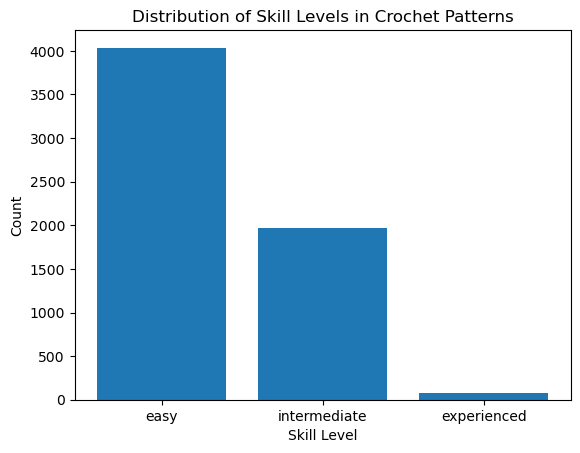

In [30]:
# create a bar chart to show the distribution of skill levels
skill_counts = combined_df["skill_level"].value_counts()
plt.bar(skill_counts.index, skill_counts.values)
plt.xlabel("Skill Level")
plt.ylabel("Count")
plt.title("Distribution of Skill Levels in Crochet Patterns")
plt.show()

In [35]:
# explore the type of projects in the dataset
project_counts = combined_df["file_name"].value_counts()
print("Total number of unique project types:", len(project_counts))
print(project_counts.head(20))

Total number of unique project types: 55
file_name
Afghans_Blankets.json              1591
Hats.json                           424
Sweaters+%26+Cardigans.json         357
Shawls+%26+Wraps.json               330
Scarves.json                        304
Pillows+%26+Poufs.json              293
Amigurumi+%26+Toys.json             286
Bags+%26+Purses.json                249
Décor.json                         231
Dishcloths.json                     222
Cowls.json                          154
Baskets.json                        118
Sets.json                           111
Placemats+%26+Table+Décor.json     100
Other+Accessories.json               99
Capes+%26+Ponchos.json               85
Tops.json                            66
Vests.json                           64
Gloves+%26+Mittens.json              64
Cozies.json                          61
Name: count, dtype: int64
